In [9]:
import os
import pandas as pd
import pickle

results_path = os.path.join("results", "results.pkl")
if os.path.exists(results_path): 
    with open(results_path, "rb") as f: 
        results_library = pickle.load(f)
else: 
    results_library = {}

In [10]:
results_df = pd.DataFrame(results_library).round(4)

columns = [
    "model_signature", 
    "best_test_accuracy", 
    #"best_train_accuracy", 
    "mean_test_accuracy", 
    #"mean_train_accuracy", 
    "learning_rate", 
    "epochs", 
    "layer_sizes"
]
results_df[columns].round(3).sort_values(by="mean_test_accuracy", ascending=False)

,model_signature,best_test_accuracy,mean_test_accuracy,learning_rate,epochs,layer_sizes
20,d5_p1186826_e2000_98_20251202_0112_deeplearning,0.990,0.976,0.005,2000,"(768, 512), (512, 512), (512, 512), (512, 512)..."
29,d5_p1186826_e2000_a97_20251203_deeplearning,0.990,0.974,0.005,2000,"(768, 512), (512, 512), (512, 512), (512, 512)..."
26,d5_p1186826_e2000_a97_20251202_deeplearning,0.990,0.974,0.005,2000,"(768, 512), (512, 512), (512, 512), (512, 512)..."
25,d5_p1186826_e2000_a97_20251202_deeplearning,0.990,0.974,0.005,2000,"(768, 512), (512, 512), (512, 512), (512, 512)..."
17,d5_p1186826_e2000_97_20251201_2107_deeplearning,0.990,0.974,0.005,2000,"(768, 512), (512, 512), (512, 512), (512, 512)..."
14,d4_p924170_e1200_97_20251201_1822,0.990,0.973,0.005,1200,"(768, 512), (512, 512), (512, 512), (512, 10)"
24,d5_p1186826_e1000_97_20251202_deeplearning,0.990,0.973,0.005,1000,"(768, 512), (512, 512), (512, 512), (512, 512)..."
23,d5_p1186826_e1000_97_20251202_deeplearning,0.990,0.973,0.005,1000,"(768, 512), (512, 512), (512, 512), (512, 512)..."
15,d4_p924170_e1500_97_20251201_1912,0.990,0.973,0.005,1500,"(768, 512), (512, 512), (512, 512), (512, 10)"
19,d4_p924170_e2000_97_20251201_2341_deeplearning,0.990,0.972,0.005,2000,"(768, 512), (512, 512), (512, 512), (512, 10)"


In [11]:
signatures = list(results_df["model_signature"])
signatures_sorted = sorted(signatures, key=len)[::-1]

for model_signature in signatures_sorted: 

    results_dir = os.path.join("results", model_signature)

    # Create a new directory for model results
    results_dir = os.path.join("results", model_signature)
    figs_dir = os.path.join(results_dir, "figures")
    model_dir = os.path.join(results_dir, "model")
    others_dir = os.path.join(results_dir, "others")
    if not os.path.exists(results_dir): os.mkdir(results_dir)
    if not os.path.exists(figs_dir): os.mkdir(figs_dir)
    if not os.path.exists(model_dir): os.mkdir(model_dir)
    if not os.path.exists(others_dir): os.mkdir(others_dir)

    for fig_name in os.listdir(os.path.join("figures")): 
        if model_signature in fig_name: 
            old_path = os.path.join("figures", fig_name)
            new_path = os.path.join(figs_dir, fig_name)
            os.replace(old_path, new_path)

    for fig_name in os.listdir(os.path.join(".")): 
        if model_signature in fig_name and ".png" in fig_name: 
            old_path = os.path.join(".", fig_name)
            new_path = os.path.join(figs_dir, fig_name)
            os.replace(old_path, new_path)

    for file_name in os.listdir("results"): 
        if ".pkl" in file_name and model_signature in file_name: 
            old_path = os.path.join("results", file_name)
            new_path = os.path.join(results_dir, file_name)
            os.replace(old_path, new_path)

    for file_name in os.listdir("trained_models"): 
        if model_signature in file_name: 
            old_path = os.path.join("trained_models", file_name)
            new_path = os.path.join(model_dir, file_name)
            os.replace(old_path, new_path)

True
0.9900
0.9700
0.9700
0.9800
0.9700


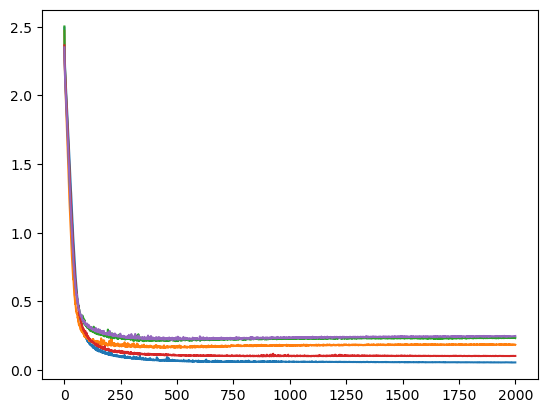

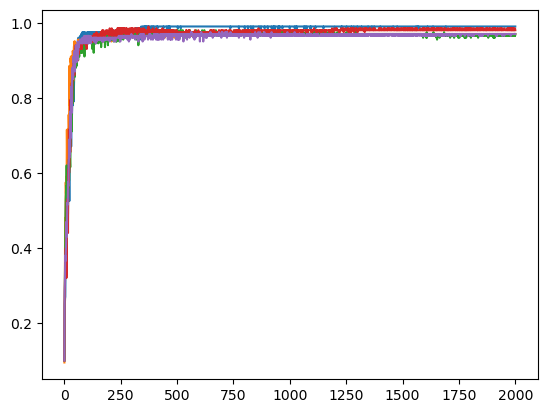

In [21]:
import matplotlib.pyplot as plt
signature = "d5_p1186826_e2000_98_20251202_0112_deeplearning"

path = os.path.join("results", signature, f"{signature}_kfold.pkl")

print(os.path.exists(path)) 

with open(path, "rb") as f: 
    kfold_results = pickle.load(f)


for fold_result in kfold_results: 

    plt.plot(fold_result["loss_history"])

plt.figure()
for fold_result in kfold_results: 

    plt.plot(fold_result["accuracy_history"])
    print(f"{fold_result["accuracy_history"][-1]:.4f}")

